In [20]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hummaamqaasim/jobs-in-data")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\user\.cache\kagglehub\datasets\hummaamqaasim\jobs-in-data\versions\6


In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('jobs_in_data.csv')

#We consider only company located in the United States
df_US = df[df['company_location'] == 'United States']
df_US

,work_year,job_title,job_category,salary_currency,salary,salary_in_usd,employee_residence,experience_level,employment_type,work_setting,company_location,company_size
1,2023,Data Architect,Data Architecture and Modeling,USD,186000,186000,United States,Senior,Full-time,In-person,United States,M
2,2023,Data Architect,Data Architecture and Modeling,USD,81800,81800,United States,Senior,Full-time,In-person,United States,M
3,2023,Data Scientist,Data Science and Research,USD,212000,212000,United States,Senior,Full-time,In-person,United States,M
4,2023,Data Scientist,Data Science and Research,USD,93300,93300,United States,Senior,Full-time,In-person,United States,M
5,2023,Data Scientist,Data Science and Research,USD,130000,130000,United States,Senior,Full-time,Remote,United States,M
...,...,...,...,...,...,...,...,...,...,...,...,...
9350,2021,Data Specialist,Data Management and Strategy,USD,165000,165000,United States,Senior,Full-time,Remote,United States,L
9351,2020,Data Scientist,Data Science and Research,USD,412000,412000,United States,Senior,Full-time,Remote,United States,L
9352,2021,Principal Data Scientist,Data Science and Research,USD,151000,151000,United States,Mid-level,Full-time,Remote,United States,L
9353,2020,Data Scientist,Data Science and Research,USD,105000,105000,United States,Entry-level,Full-time,Remote,United States,S


In [46]:
#FOCUS ON POPULAR JOB TITLE
#salary trend of data analyst job over the year?
#work_setting salary comparison (i.e. remote vs in-person vs hybrid)
	#compare only the same level of experience to avoid skewed distribution.

#salary comparison of job titles (entry level vs entry level, ... , exec vs exec)
#check which company size offers more salary


#advanced: linear regression for salary of data analyst, data scientist
    #find out if job_title is significant factor in salary
    #
df['job_title'].value_counts()

job_title
Data Engineer                     2195
Data Scientist                    1989
Data Analyst                      1388
Machine Learning Engineer          991
Applied Scientist                  272
                                  ... 
Consultant Data Engineer             1
Sales Data Analyst                   1
Managing Director Data Science       1
AWS Data Architect                   1
Deep Learning Researcher             1
Name: count, Length: 125, dtype: int64

In [24]:
#data cleaning
#check for missing values
df.isnull().sum()

work_year             0
job_title             0
job_category          0
salary_currency       0
salary                0
salary_in_usd         0
employee_residence    0
experience_level      0
employment_type       0
work_setting          0
company_location      0
company_size          0
dtype: int64

In [25]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9355 entries, 0 to 9354
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   work_year           9355 non-null   int64 
 1   job_title           9355 non-null   object
 2   job_category        9355 non-null   object
 3   salary_currency     9355 non-null   object
 4   salary              9355 non-null   int64 
 5   salary_in_usd       9355 non-null   int64 
 6   employee_residence  9355 non-null   object
 7   experience_level    9355 non-null   object
 8   employment_type     9355 non-null   object
 9   work_setting        9355 non-null   object
 10  company_location    9355 non-null   object
 11  company_size        9355 non-null   object
dtypes: int64(3), object(9)
memory usage: 877.2+ KB


,work_year,salary,salary_in_usd
count,9355.000000,9355.000000,9355.000000
mean,2022.760449,149927.981293,150299.495564
std,0.519470,63608.835387,63177.372024
min,2020.000000,14000.000000,15000.000000
25%,2023.000000,105200.000000,105700.000000
50%,2023.000000,143860.000000,143000.000000
75%,2023.000000,187000.000000,186723.000000
max,2023.000000,450000.000000,450000.000000


C:\Users\user\AppData\Local\Temp\ipykernel_7336\2702859270.py:6: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_top3[df['job_title'] == 'Data Scientist']['salary_in_usd'].plot(kind='kde')


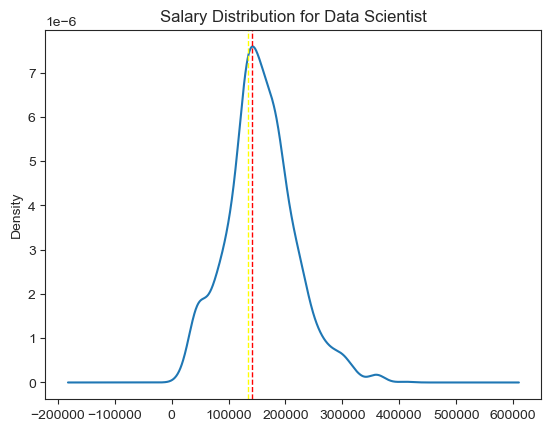

In [ ]:
top_3_job = df['job_title'].value_counts().head(3).index.to_list()

#gather data filtering top_3_job only
df_top3 = df[df['job_title'].isin(top_3_job)].copy()

df_top3[df['job_title'] == 'Data Scientist']['salary_in_usd'].plot(kind='kde')
mean_value = df_top3['salary_in_usd'].mean()
median_value = df_top3['salary_in_usd'].median()
plt.axvline(mean_value, color='red', linestyle='dashed', linewidth=1, label='Mean')
plt.axvline(median_value, color='yellow', linestyle='dashed', linewidth=1, label='Mean')
plt.title('Salary Distribution for Data Scientist')
plt.show()


#seems like the salary distribution of top 3 data jobs slightly skewed to the right, suggesting mode is much lower than mean value.
#Does this indicate that this data contains of entry level jobs that skewed the distribution?
#might consider analysis by experience level instead of general due to not normal distribution.


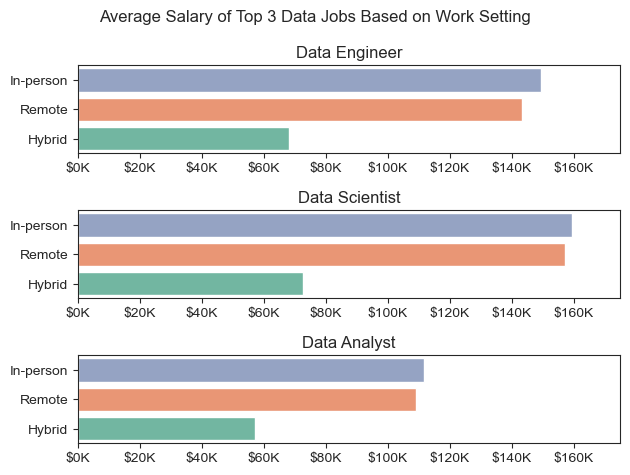

In [27]:
#work_setting salary comparison (i.e. remote vs in-person vs hybrid)
#compare same job title, different work setting
#clean the plot using sns

mean_df = df_top3.groupby(['job_title', 'work_setting'])['salary_in_usd'].mean()
mean_df = mean_df.reset_index(name='mean_salary')
mean_df = mean_df.sort_values(by='mean_salary', ascending=False)
fig, ax = plt.subplots(3,1)
sns.set_style(style='ticks')
for i,job in enumerate(top_3_job):
    mean_df_plot = mean_df[mean_df['job_title'] == job]
    sns.barplot(data=mean_df_plot, y='work_setting', x='mean_salary', legend=False, ax=ax[i], palette='Set2', hue='mean_salary')
    ax[i].set_ylabel('')
    ax[i].set_xlim(0,175000)
    ax[i].set_xlabel('')
    ax[i].set_title(job)
    ax[i].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'${int(x/1000)}K'))
plt.suptitle('Average Salary of Top 3 Data Jobs Based on Work Setting')
plt.tight_layout()
plt.show()

#we see a trend where Hybrid jobs pays only more or less half as the other 2 work settings.
#deep dive for the reason why is this happening.


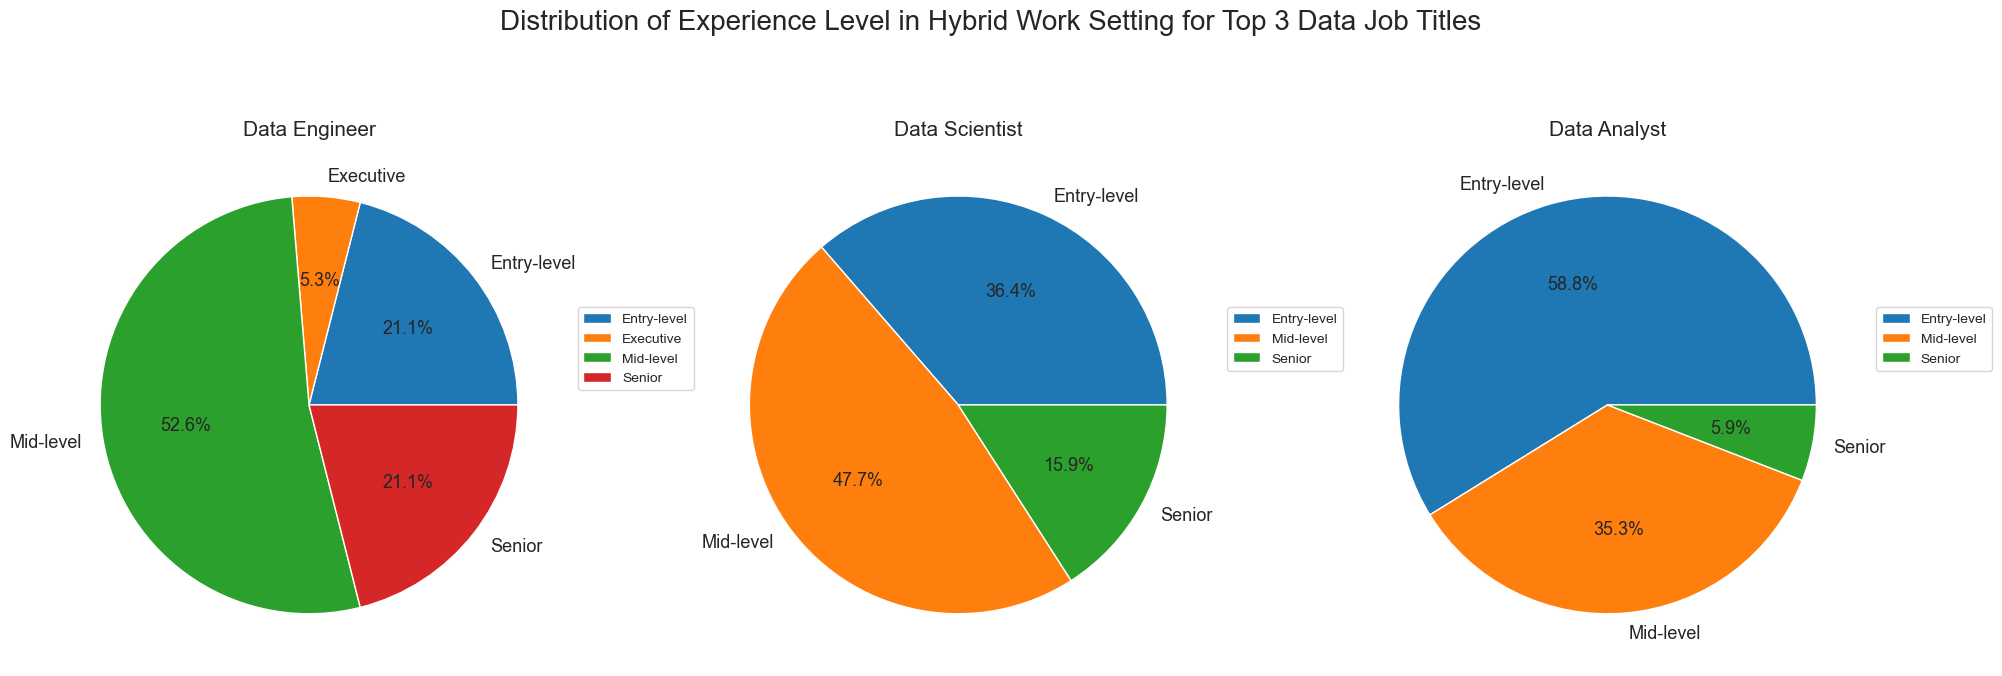

In [28]:
#exploring the reason behind hybrid work setting pays significantly less than the others.
#produce graph showing hybrid work setting does not offer an executive position and hence, no salary, which causes for Hybrid mean salary to drop significantly.
df_hybrid = df_top3.groupby(['job_title', 'work_setting', 'experience_level'],dropna=False).size()
df_hybrid = df_hybrid.reset_index(name='job_count')
df_hybrid = df_hybrid[df_hybrid['job_title'].isin(top_3_job)]
df_hybrid = df_hybrid[df_hybrid['work_setting'] == 'Hybrid']
df_hybrid = df_hybrid.set_index('job_title')

fig,ax = plt.subplots(1,3, figsize=(20,15))
for i,job in enumerate(top_3_job):
    ax[i].pie(data=df_hybrid.loc[job], x='job_count', labels=df_hybrid.loc[job]['experience_level'], autopct='%1.1f%%', textprops={'fontsize': 13})
    ax[i].set_title(job, fontsize=15)
    ax[i].legend(loc='upper right', bbox_to_anchor=(1.25,0.7))
plt.suptitle('Distribution of Experience Level in Hybrid Work Setting for Top 3 Data Job Titles', y=0.75, fontsize=20)
plt.tight_layout()
#as can be observed, both DS and DA does not have Hybrid setting for executive position. Also, one can notice that Data Engineer has executive position, but only for 5%.
#this causes mean salary for hybrid work setting to be significantly lower.
#adjust to show 3 pie charts in single graph

In [29]:
mean_df

,job_title,work_setting,mean_salary
7,Data Scientist,In-person,159478.334495
8,Data Scientist,Remote,157291.435383
4,Data Engineer,In-person,149466.958904
5,Data Engineer,Remote,143505.045627
1,Data Analyst,In-person,111579.544402
2,Data Analyst,Remote,109242.311448
6,Data Scientist,Hybrid,72639.477273
3,Data Engineer,Hybrid,68155.578947
0,Data Analyst,Hybrid,57052.058824


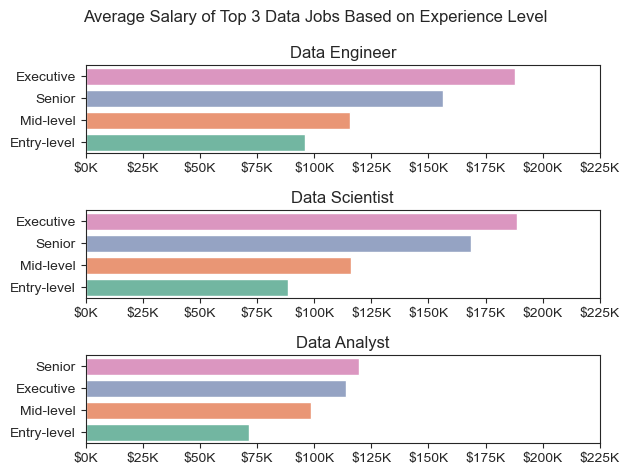

In [30]:
#explore the analysis for entry level experience only.
#eventually compare different job role for different experience to compare which salary growth is more rewarding.

mean_df = df_top3.groupby(['job_title', 'experience_level'])['salary_in_usd'].mean()
mean_df = mean_df.reset_index(name='mean_salary')
mean_df = mean_df.sort_values(by='mean_salary', ascending=False)
fig, ax = plt.subplots(3,1)
sns.set_style(style='ticks')
for i,job in enumerate(top_3_job):
    mean_df_plot = mean_df[mean_df['job_title'] == job]
    sns.barplot(data=mean_df_plot, y='experience_level', x='mean_salary', legend=False, ax=ax[i], palette='Set2', hue='mean_salary')
    ax[i].set_ylabel('')
    ax[i].set_xlim(0,225000)
    ax[i].set_xlabel('')
    ax[i].set_title(job)
    ax[i].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos: f'${int(x/1000)}K'))
plt.suptitle('Average Salary of Top 3 Data Jobs Based on Experience Level')
plt.tight_layout()
plt.show()

#data analyst has the lowest salary in all experience level
#data engineer has the highest salary for entry-level
#while data scientist has the largest growth over experience level.

In [31]:
df_counts = df.groupby(['job_title', 'work_year']).size()
df_counts.loc[['Data Scientist', 'Data Analyst', 'Data Engineer']]

job_title       work_year
Data Scientist  2020           19
                2021           34
                2022          398
                2023         1538
Data Analyst    2020            6
                2021           19
                2022          272
                2023         1091
Data Engineer   2020           11
                2021           35
                2022          487
                2023         1662
dtype: int64

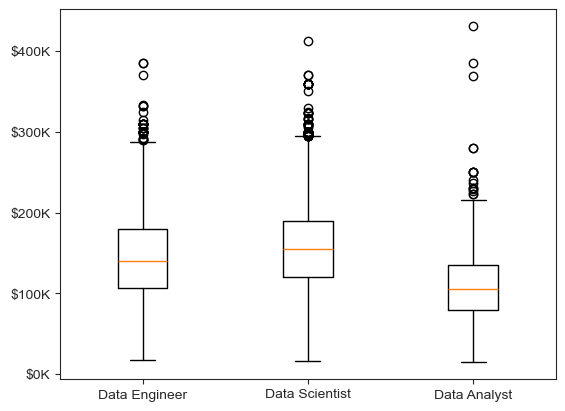

In [32]:
job_list = [df[df['job_title'] == job]['salary_in_usd']for job in top_3_job]
job_list

plt.boxplot(job_list, tick_labels=top_3_job)
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y,pos: f'${int(y/1000)}K'))
plt.show()

In [43]:
df[df['job_title'] == 'Data Analyst']['salary_in_usd'].sort_values(ascending=False).head()
df.iloc[7683:7684]

,work_year,job_title,job_category,salary_currency,salary,salary_in_usd,employee_residence,experience_level,employment_type,work_setting,company_location,company_size
7683,2022,Data Analyst,Data Analysis,GBP,350000,430967,United Kingdom,Mid-level,Full-time,In-person,United Kingdom,M
